## MeWe-KI Übung 01
**Author: Hadis Fayz, BSc**<br>
**Train - Test - Split** \
Variable convention: Feature data with a capital X, labels with lower case y

For help, see the scikit learn documentary:

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

In [11]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

### Numerical y - variable (Head size vs. Brain weight)

1. Read & view data

In [12]:
data = pd.read_csv('headbrain.csv')
print(f'There are {data.size} observations in this data set.')
data.head()

There are 474 observations in this data set.


,Head Size(cm^3),Brain Weight(grams)
0,4512,1530
1,3738,1297
2,4261,1335
3,3777,1282
4,4177,1590


In [13]:
X = data[['Head Size(cm^3)']]
y = data[['Brain Weight(grams)']]

2. Split data into a training set (80%) and a test set (20%). \
Make sure your split is repeatable, i.e., your data is split in the same way every time. \
Be sure to understand the parameters you are using.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
print(f'Samples in Training Data: {X_train.size} \nSamples in test data: {y_train.size}')

Samples in Training Data: 189 
Samples in test data: 189


3. Split the data into a training (70%), validation (15%) and test (15%) set. \
Again, make sure your split is repeatable.

In [16]:
#your code goes here
#name the variables X_train, X_val, X_test, y_train, y_val, y_test

from sklearn.model_selection import train_test_split

# First split umfasst Train (60%) und Temp (40%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    random_state=42
)

# Second split umfasst Validation (20%) und Test (20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42
)

print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.shape, y_val.shape, y_test.shape)

(142, 1) (47, 1) (48, 1)
(142, 1) (47, 1) (48, 1)


In [17]:
print(f'Samples in Training Data: {X_train.size} \nSamples in validation data: {X_val.size} \nSamples in test data: {X_test.size}')

Samples in Training Data: 142 
Samples in validation data: 47 
Samples in test data: 48


### Categorial y - variable (Iris Dataset)

1. Prepare & view data

In [18]:
from sklearn import datasets
iris = datasets.load_iris()
X = pd.DataFrame(data=iris.data,
                  columns=iris.feature_names)
print(f'There are {X.size} observations in this data set.')
X.head()

There are 600 observations in this data set.


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [19]:
y = pd.DataFrame(iris.target, columns = ['species'])
y['species'] = y['species'].map(dict(enumerate(iris.target_names)))
y.sample(5, random_state = 1303)

,species
3,setosa
138,virginica
112,virginica
80,versicolor
37,setosa


2. Perform "normal" train-validation-test split (75/15/10) \
    Make your split repeatable.

In [20]:
#your code goes here
#name the variables X_train, X_val, X_test, y_train, y_val, y_test

from sklearn.model_selection import train_test_split
# First split umfasst Train (60%) und Temp (40%)
X_train, X_temp, y_train, y_temp = train_test_split(
  X, y,
  test_size=0.4,
  random_state=42
)
# Second split umfasst Validation (20%) und Test (20%)
X_val, X_test, y_val, y_test = train_test_split(
  X_temp, y_temp,
  test_size=0.5,
  random_state=42
)
print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.shape, y_val.shape, y_test.shape)

(90, 4) (30, 4) (30, 4)
(90, 1) (30, 1) (30, 1)


Check distribution of categories in each data set.

In [21]:
#Function to visualize class distribution
def category_percentages(dfs: dict, column: str, plot=True, normalize=True):

    results = {}
    for name, d in dfs.items():
        counts = d[column].value_counts(normalize=normalize) * (100 if normalize else 1)
        results[name] = counts
    summary = pd.DataFrame(results).T.fillna(0)
    if plot:
        ax = summary.plot(kind="bar", stacked=True, figsize=(9, 6))
        ax.set_ylabel("Percentage (%)" if normalize else "Count")
        ax.set_title(f"Distribution of {column} per DataFrame")
        ax.legend(title="Categories", bbox_to_anchor=(1.02, 1), loc="upper left")
        ax.grid(True, axis="y", linestyle="--", alpha=0.4)
        plt.tight_layout()
        plt.show()
    return summary

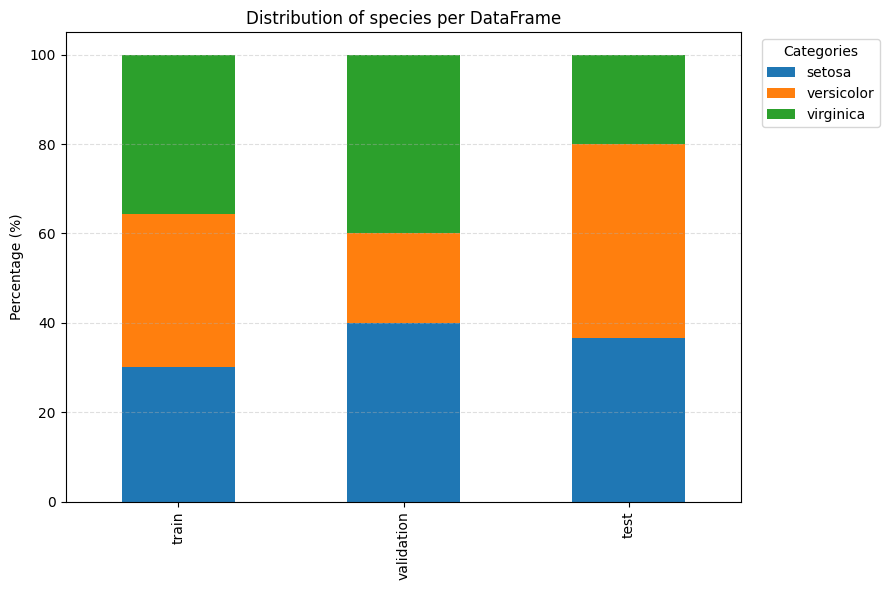

species        setosa  versicolor  virginica
train       30.000000   34.444444  35.555556
validation  40.000000   20.000000  40.000000
test        36.666667   43.333333  20.000000


In [22]:
# Visualize:
dfs = {"train": y_train, "validation": y_val, "test": y_test}
summary = category_percentages(dfs, column="species")
print(summary)


3. Since the classes are (likely) not distributed evenly, we need to fix this. Otherwise we introduce a bias into our data. \
    Again, perform train-validation-test split (75/15/10) \
    This time, ensure that the categories are represented EVENLY in each part. \
    Make your split repeatable.

In [23]:
#your code goes here
#name variables X_train, X_val, X_test, y_train, y_val, y_test

from sklearn.model_selection import train_test_split

# First split umfasst 90% temp, 10% test
X_temp, X_test, y_temp, y_test = train_test_split(
  X,
  y,
  test_size=0.10,
  random_state=42,
  stratify=y
)

# Second split umfasst 75/15 from remaining 90%
X_train, X_val, y_train, y_val = train_test_split(
  X_temp,
  y_temp,
  test_size=1/6, # 15% of total data
  random_state=42,
  stratify=y_temp
)

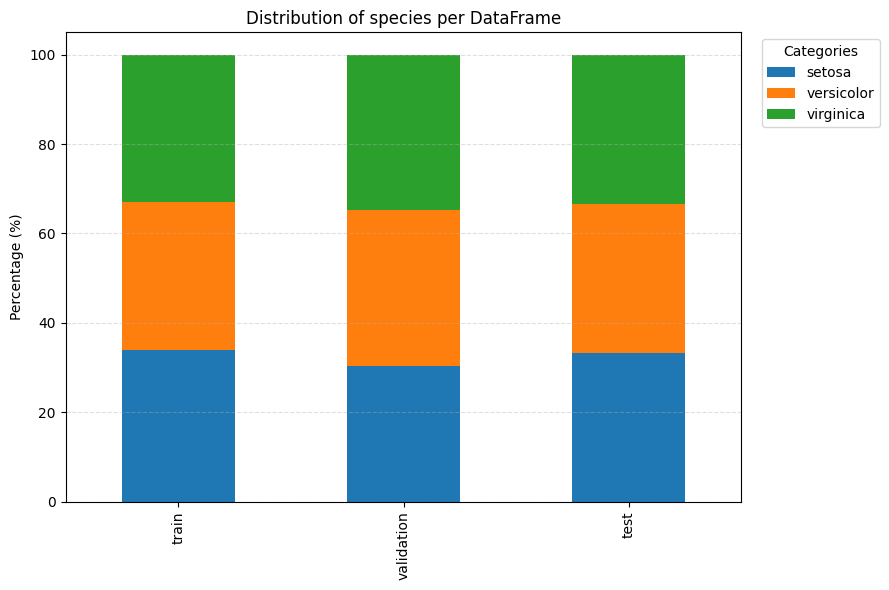

species        setosa  versicolor  virginica
train       33.928571   33.035714  33.035714
validation  30.434783   34.782609  34.782609
test        33.333333   33.333333  33.333333


In [24]:
# Visualize:
dfs = {"train": y_train, "validation": y_val, "test": y_test}
summary = category_percentages(dfs, column="species")
print(summary)